In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

In [2]:
df= pd.read_csv("millets_value_chain_2015_2026.csv")

In [3]:
df

,Year,Season,State,District,Crop,Crop_Category,Area_Sown_Current_ha,Area_Sown_Last_Year_ha,Area_Sown_3yr_Avg_ha,Area_Growth_Rate_percent,...,Total_Rainfall_mm,Rainfall_Deviation_percent,Avg_Temperature_C,Max_Temperature_C,Min_Temperature_C,Avg_Humidity_percent,Extreme_Heat_Days,Extreme_Rain_Days,Drought_Index,Production_tons
0,2015,Kharif,Rajasthan,Barmer,Pearl Millet,millets,50534.32,52957.01,52679.13,-4.57,...,317.88,-14.70,29.05,34.24,23.06,66.00,17,13,0.000,80093.72
1,2015,Kharif,Rajasthan,Barmer,Finger Millet,millets,60495.41,61910.55,62408.02,-2.29,...,506.37,-11.48,24.43,32.65,18.81,76.89,2,17,0.000,122389.87
2,2015,Kharif,Rajasthan,Barmer,Sorghum,millets,72228.51,71408.88,70502.41,1.15,...,528.08,1.74,32.34,38.48,25.56,66.81,22,20,0.000,142292.19
3,2015,Kharif,Rajasthan,Barmer,Foxtail Millet,millets,44682.79,45060.49,45583.35,-0.84,...,333.56,27.53,32.05,39.86,26.72,76.53,18,10,0.000,50212.93
4,2015,Kharif,Rajasthan,Barmer,Kodo Millet,millets,75581.28,71351.24,70128.17,5.93,...,517.20,39.81,25.38,33.84,16.60,74.44,4,20,0.000,60106.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3835,2026,Kharif,Uttar Pradesh,Etawah,Foxtail Millet,millets,11331.91,11427.91,11311.76,-0.84,...,580.21,39.62,27.96,37.26,18.75,74.79,23,1,1.810,11021.94
3836,2026,Kharif,Uttar Pradesh,Etawah,Kodo Millet,millets,56180.00,51709.34,50465.74,8.65,...,497.89,34.17,27.82,38.17,22.00,45.12,14,8,0.000,113334.46
3837,2026,Rabi,Uttar Pradesh,Etawah,Barnyard Millet,millets,87829.91,79334.92,80615.56,10.71,...,806.47,31.65,28.00,35.14,18.14,73.00,23,3,0.000,97977.16
3838,2026,Rabi,Uttar Pradesh,Etawah,Little Millet,millets,87902.83,83905.55,83133.98,4.76,...,607.78,38.17,30.90,42.66,25.60,46.22,3,16,0.668,83947.01


In [4]:
df["Crop"].value_counts()


Crop
Pearl Millet       480
Finger Millet      480
Sorghum            480
Foxtail Millet     480
Kodo Millet        480
Barnyard Millet    480
Little Millet      480
Proso Millet       480
Name: count, dtype: int64

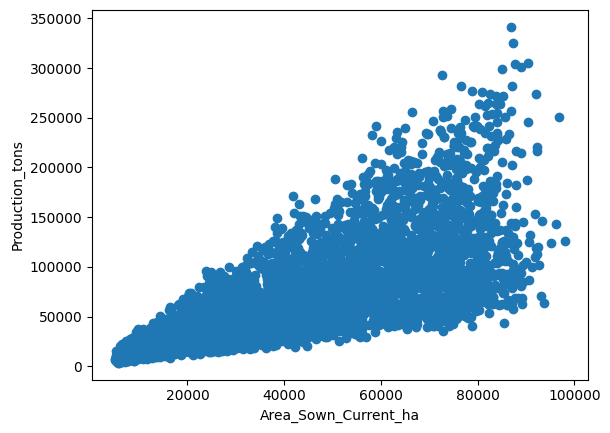

In [5]:
plt.scatter(df['Area_Sown_Current_ha'], df['Production_tons'])

plt.xlabel("Area_Sown_Current_ha")
plt.ylabel("Production_tons")

plt.show()

In [6]:
le = LabelEncoder()


In [7]:
df['Season'] = le.fit_transform(df['Season'])
df['State'] = le.fit_transform(df['State'])
df['District'] = le.fit_transform(df['District'])
df['Crop'] = le.fit_transform(df['Crop'])
df['Area_Sown_Current_ha'] = le.fit_transform(df['Area_Sown_Current_ha'])




In [8]:
df = df.drop('Crop_Category', axis=1)
df = df.drop('Year', axis=1)

In [9]:
x = df.drop("Production_tons" , axis=1)
y = df["Production_tons"]

In [10]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

# Model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)



In [11]:

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 38175240.43758278
RMSE: 6178.611529913722
MAE: 4032.8677179463702
R2 Score: 0.985957065823109


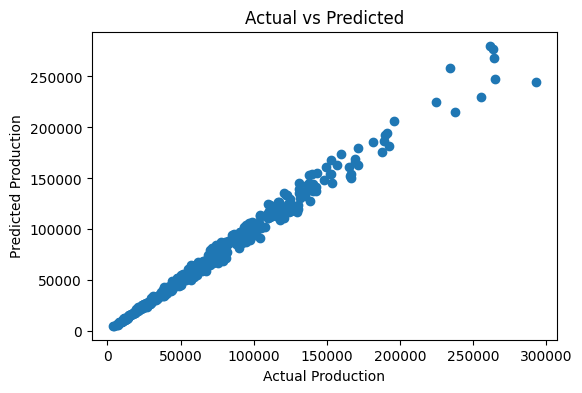

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted")

plt.show()

In [13]:
print(df["Production_tons"].describe())


count      3840.000000
mean      75895.289174
std       53687.112681
min        3478.110000
25%       34809.432500
50%       64383.870000
75%      103339.125000
max      341542.630000
Name: Production_tons, dtype: float64


In [14]:
print("Error Percentage:", (rmse / y.mean()) * 100)

Error Percentage: 8.140968427841981
